# Phase 1 — Exploration des données UNSW-NB15

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', 50)
print('libs OK')

libs OK


## 1. Chargement du dataset

In [2]:
train = pd.read_csv('../data/UNSW_NB15_training-set.csv')
test  = pd.read_csv('../data/UNSW_NB15_testing-set.csv')
print('Train shape:', train.shape)
print('Test shape :', test.shape)
train.head()

Train shape: (82332, 45)
Test shape : (175341, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.000011,udp,-,INT,2,0,496,0,90909.0902,254,0,180363632.0,0.0,0,0,0.011,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,248,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
1,2,0.000008,udp,-,INT,2,0,1762,0,125000.0003,254,0,881000000.0,0.0,0,0,0.008,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,881,0,0,0,2,2,1,1,1,2,0,0,0,1,2,0,Normal,0
2,3,0.000005,udp,-,INT,2,0,1068,0,200000.0051,254,0,854400000.0,0.0,0,0,0.005,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,534,0,0,0,3,2,1,1,1,3,0,0,0,1,3,0,Normal,0
3,4,0.000006,udp,-,INT,2,0,900,0,166666.6608,254,0,600000000.0,0.0,0,0,0.006,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,450,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0
4,5,0.000010,udp,-,INT,2,0,2126,0,100000.0025,254,0,850400000.0,0.0,0,0,0.010,0.0,0.0,0.0,0,0,0,0,0.0,0.0,0.0,1063,0,0,0,3,2,2,2,1,3,0,0,0,2,3,0,Normal,0


## 2. Les colonnes disponibles

In [3]:
print('Colonnes :', train.columns.tolist())
print('\nTypes :')
print(train.dtypes)

Colonnes : ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']

Types :
id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64

## 3. Distribution des classes (normal vs attaque)

--- TRAIN ---
label
1    45332
0    37000
Name: count, dtype: int64
Ratio attaque : 55.1%

--- TEST ---
label
1    119341
0     56000
Name: count, dtype: int64


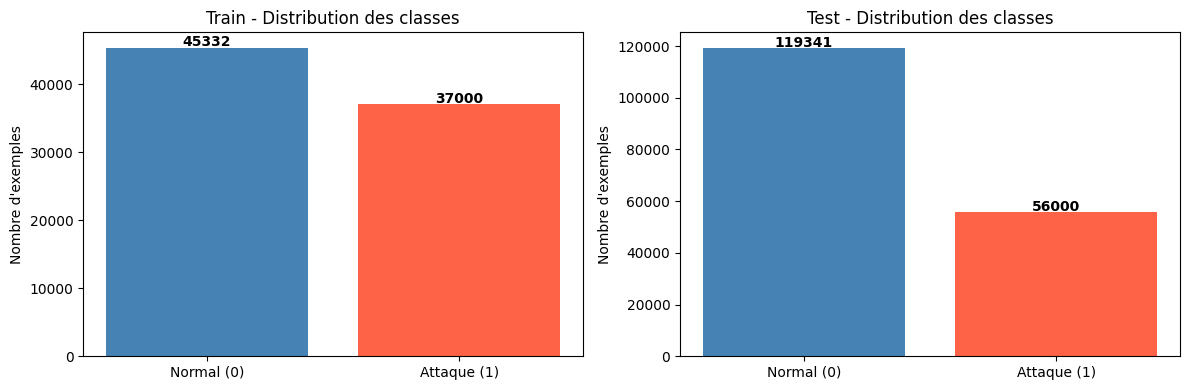

In [4]:
print('--- TRAIN ---')
print(train['label'].value_counts())
print(f"Ratio attaque : {train['label'].mean()*100:.1f}%")
print('\n--- TEST ---')
print(test['label'].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    counts = df['label'].value_counts()
    ax.bar(['Normal (0)', 'Attaque (1)'], counts.values, color=['steelblue', 'tomato'])
    ax.set_title(f'{title} - Distribution des classes')
    ax.set_ylabel("Nombre d'exemples")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 200, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../results/class_distribution.png', dpi=150)
plt.show()

## 4. Types d'attaques

Types d'attaques :
attack_cat
Normal            37000
Generic           18871
Exploits          11132
Fuzzers            6062
DoS                4089
Reconnaissance     3496
Analysis            677
Backdoor            583
Shellcode           378
Worms                44
Name: count, dtype: int64


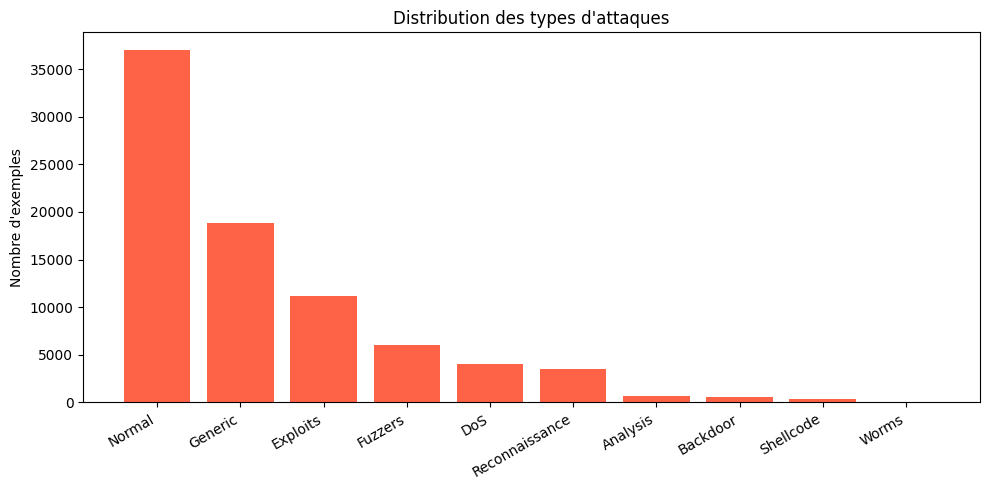

In [5]:
if 'attack_cat' in train.columns:
    print("Types d'attaques :")
    print(train['attack_cat'].value_counts())
    plt.figure(figsize=(10, 5))
    counts = train['attack_cat'].value_counts()
    plt.bar(counts.index, counts.values, color='tomato')
    plt.xticks(rotation=30, ha='right')
    plt.title("Distribution des types d'attaques")
    plt.ylabel("Nombre d'exemples")
    plt.tight_layout()
    plt.savefig('../results/attack_types.png', dpi=150)
    plt.show()

## 5. Valeurs manquantes et aberrantes

In [6]:
missing = train.isnull().sum()
missing = missing[missing > 0]
print('Valeurs manquantes:', len(missing), 'colonnes')
if len(missing) > 0:
    print(missing)

num_cols = train.select_dtypes(include=np.number).columns
inf_count = np.isinf(train[num_cols]).sum()
inf_count = inf_count[inf_count > 0]
print('\nValeurs infinies:', len(inf_count), 'colonnes')
if len(inf_count) > 0:
    print(inf_count)

Valeurs manquantes: 0 colonnes

Valeurs infinies: 0 colonnes


## 6. Distribution des features cles : Normal vs Attaque

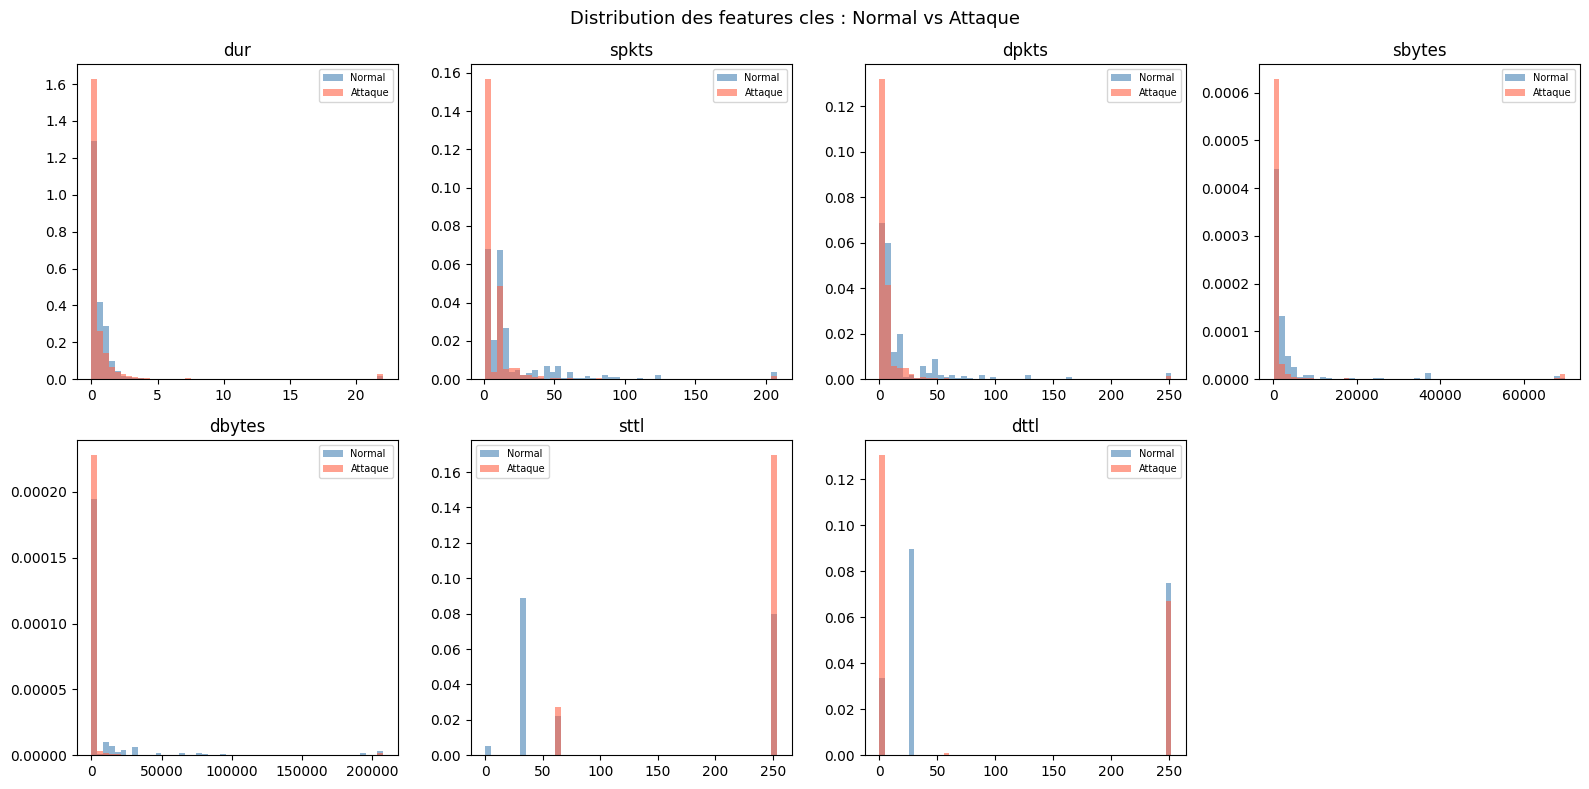

In [7]:
key_features = ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'sttl', 'dttl']
key_features = [f for f in key_features if f in train.columns]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    normal = train[train['label'] == 0][feat].replace([np.inf, -np.inf], np.nan).dropna()
    attack = train[train['label'] == 1][feat].replace([np.inf, -np.inf], np.nan).dropna()
    clip_val = train[feat].replace([np.inf, -np.inf], np.nan).quantile(0.99)
    axes[i].hist(normal.clip(upper=clip_val), bins=50, alpha=0.6, color='steelblue', label='Normal', density=True)
    axes[i].hist(attack.clip(upper=clip_val), bins=50, alpha=0.6, color='tomato', label='Attaque', density=True)
    axes[i].set_title(feat)
    axes[i].legend(fontsize=7)

for j in range(len(key_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution des features cles : Normal vs Attaque', fontsize=13)
plt.tight_layout()
plt.savefig('../results/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Features les plus correlees avec le label

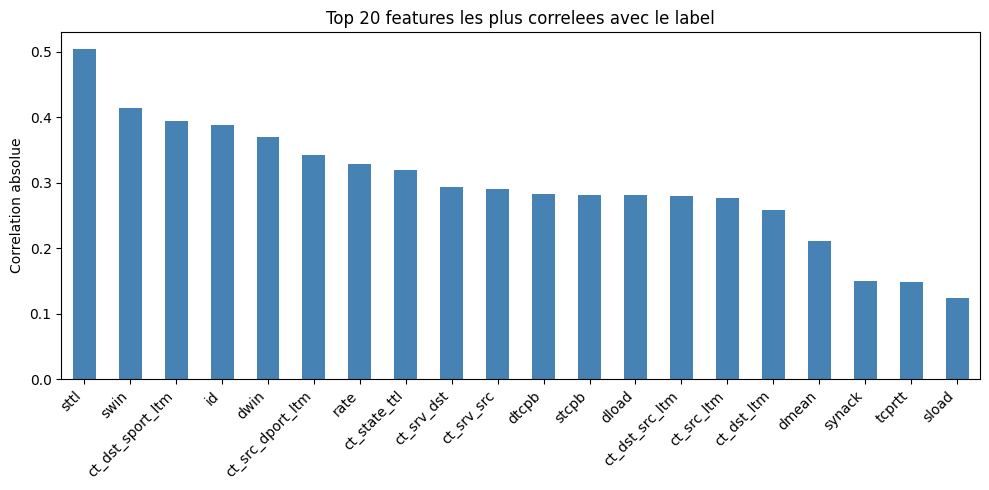

Top 10 features discriminantes :
sttl                0.504159
swin                0.414504
ct_dst_sport_ltm    0.393668
id                  0.387489
dwin                0.369257
ct_src_dport_ltm    0.341513
rate                0.328629
ct_state_ttl        0.318517
ct_srv_dst          0.292931
ct_srv_src          0.290195
Name: label, dtype: float64


In [8]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
correlations = train[num_cols].replace([np.inf, -np.inf], np.nan).corr()['label'].drop('label')
correlations = correlations.abs().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
correlations.head(20).plot(kind='bar', color='steelblue')
plt.title('Top 20 features les plus correlees avec le label')
plt.ylabel('Correlation absolue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../results/feature_correlation.png', dpi=150)
plt.show()

print('Top 10 features discriminantes :')
print(correlations.head(10))

## 8. Resume

In [9]:
print('=== RESUME EXPLORATION ===')
print(f'Train : {train.shape[0]:,} exemples, {train.shape[1]} colonnes')
print(f'Test  : {test.shape[0]:,} exemples')
print(f"Taux d'attaque train : {train['label'].mean()*100:.1f}%")
print(f"Taux d'attaque test  : {test['label'].mean()*100:.1f}%")
cat_cols = train.select_dtypes(include='object').columns.tolist()
print(f'Colonnes categorielles a encoder : {cat_cols}')
missing_total = train.isnull().sum().sum()
inf_total = np.isinf(train.select_dtypes(include=np.number)).sum().sum()
print(f'Valeurs manquantes : {missing_total}')
print(f'Valeurs infinies   : {inf_total}')
print('=> Phase 2 : preprocessing + modele baseline')

=== RESUME EXPLORATION ===
Train : 82,332 exemples, 45 colonnes
Test  : 175,341 exemples
Taux d'attaque train : 55.1%
Taux d'attaque test  : 68.1%
Colonnes categorielles a encoder : ['proto', 'service', 'state', 'attack_cat']
Valeurs manquantes : 0
Valeurs infinies   : 0
=> Phase 2 : preprocessing + modele baseline


/tmp/ipykernel_2101565/3529383796.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include='object').columns.tolist()
